In [2]:
import zipfile

with zipfile.ZipFile('/content/archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import pandas as pd

fake = pd.read_csv('/content/data/Fake.csv')
true = pd.read_csv('/content/data/True.csv')

print("Fake news articles:", len(fake))
print("Real news articles:", len(true))

Fake news articles: 23481
Real news articles: 21417


In [4]:
fake['label'] = 0
true['label'] = 1

print("Labels added successfully!")

Labels added successfully!


In [5]:
data = pd.concat([fake, true], ignore_index=True)

print("Total articles:", len(data))

Total articles: 44898


In [6]:
data = data[['text', 'label']]

print(data.head())

                                                text  label
0  Donald Trump just couldn t wish all Americans ...      0
1  House Intelligence Committee Chairman Devin Nu...      0
2  On Friday, it was revealed that former Milwauk...      0
3  On Christmas day, Donald Trump announced that ...      0
4  Pope Francis used his annual Christmas Day mes...      0


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data['text'],
    data['label'],
    test_size=0.2,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 35918
Testing data: 8980


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF conversion completed!")

TF-IDF conversion completed!


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [10]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9846325167037862
Accuracy Percentage: 98.46325167037861 %


In [11]:
news = input("Enter a news article: ")

news_tfidf = vectorizer.transform([news])
prediction = model.predict(news_tfidf)

if prediction[0] == 0:
    print("Prediction: Potentially Fake News")
else:
    print("Prediction: Potentially Real News")

Enter a news article: their will be heavy rain tomorrow
Prediction: Potentially Fake News


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("----- Model Evaluation Report -----")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

----- Model Evaluation Report -----
Accuracy  : 0.9846
Precision : 0.9824
Recall    : 0.9852
F1-Score  : 0.9838


In [13]:
import joblib

joblib.dump(model, '/content/fake_news_model.pkl')
joblib.dump(vectorizer, '/content/tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


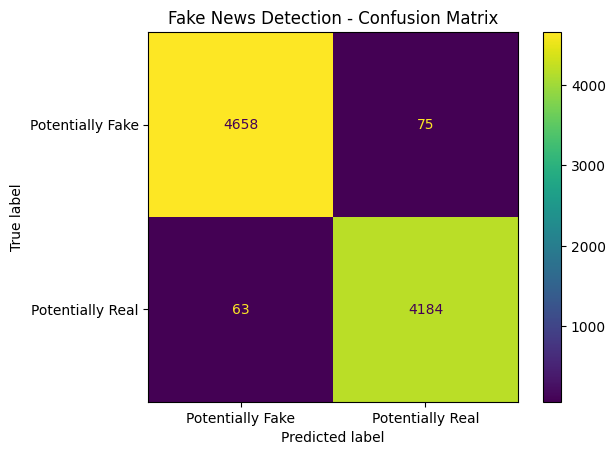

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Potentially Fake", "Potentially Real"]
)

display.plot()
plt.title("Fake News Detection - Confusion Matrix")
plt.show()

In [15]:
results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

results_df = pd.DataFrame([results])

results_df.to_csv('/content/evaluation_results.csv', index=False)

print("Evaluation results saved successfully!")

Evaluation results saved successfully!


In [16]:
print(results_df)

   Accuracy  Precision    Recall  F1-Score
0  0.984633    0.98239  0.985166  0.983776


In [17]:
from google.colab import files

files.download('/content/fake_news_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from google.colab import files

files.download('/content/tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>